<a href="https://colab.research.google.com/github/FDB1228/Optimization_methods/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Лабораторная работа №5**
Выполнил: студент группы ФН2-61 Тихомиров С.И.

---

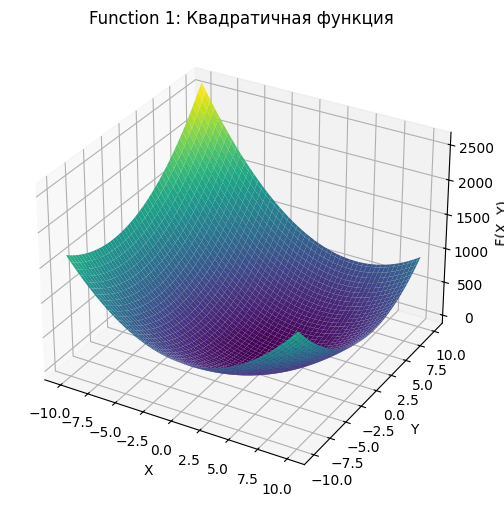

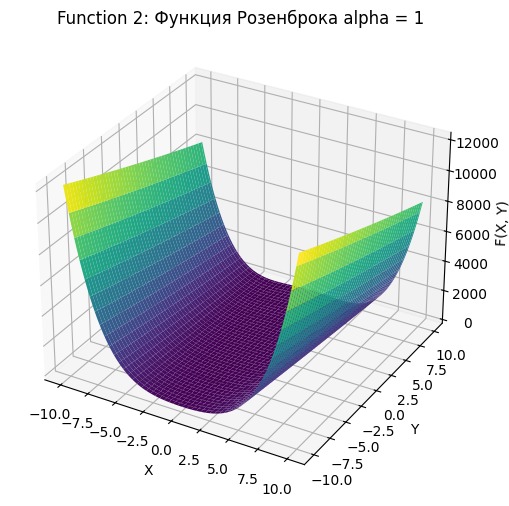

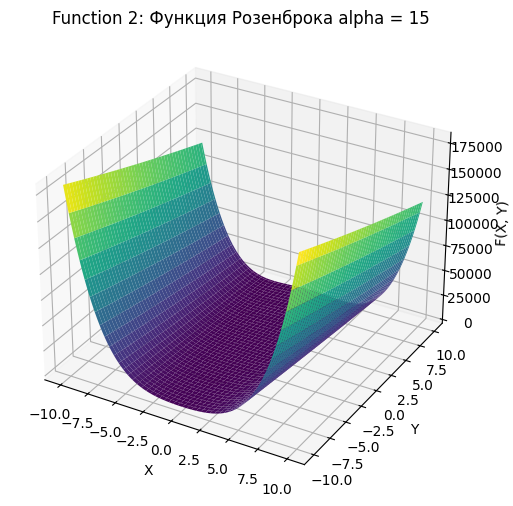

In [ ]:
# @title Визуализиция графиков квадратичной функции и функции Розенброка
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from typing import Callable, List, Tuple, Dict
from numpy.linalg import norm

# Определяем функции
def f1(x: np.ndarray) -> float:
    """Квадаратичная функция"""
    return (
        10 * x[0] ** 2
        - 4 * x[0] * x[1]
        + 7 * x[1] ** 2
        - 4 * np.sqrt(5) * (5 * x[0] - x[1])
        - 16
    )

def f2(x: np.ndarray) -> float:
    """Функция Розенброка alpha = 1"""
    return (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2

def f3(x: np.ndarray) -> float:
    """Функция Розенброка alpha = 15"""
    return 15 * (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2


# Определяем компоненты градиента
def f1dx(x: np.ndarray) -> float:
    return 20 * x[0] - 4 * x[1] - 20 * np.sqrt(5)

def f1dy(x: np.ndarray) -> float:
    return -4 * x[0] + 14 * x[1] + 4 * np.sqrt(5)

def f2dx(x: np.ndarray) -> float:
    return 4 * x[0] * ((x[0] ** 2) - x[1]) + 2 * (x[0] - 1)

def f2dy(x: np.ndarray) -> float:
    return -2 * ((x[0] ** 2) - x[1])

def f3dx(x: np.ndarray) -> float:
    return 60 * x[0] * ((x[0] ** 2) - x[1]) + 2 * (x[0] - 1)

def f3dy(x: np.ndarray) -> float:
    return -30 * ((x[0] ** 2) - x[1])

def norm(v: np.ndarray) -> float:
    """Евклидова норма вектора"""
    return np.linalg.norm(v)

def golden_section_search(
    f: Callable[[float], float], a: float, b: float, tol: float) -> float:
    """Метод золотого сечения"""
    phi = (1 + np.sqrt(5)) / 2
    resphi = 2 - phi
    f_evals = 2

    x1, x2 = a + resphi * (b - a), b - resphi * (b - a)
    f1, f2 = f(x1), f(x2)

    while abs(b - a) > tol:
        if f1 < f2:
            b, x2, f2 = x2, x1, f1
            x1 = a + resphi * (b - a)
            f1 = f(x1)
        else:
            a, x1, f1 = x1, x2, f2
            x2 = b - resphi * (b - a)
            f2 = f(x2)
        f_evals+=1
    return (a + b) / 2 , f_evals


def update_matrix(
        method_id: int,
        A: np.ndarray,
        delta_x: np.ndarray,
        delta_w: np.ndarray
    ) -> np.ndarray:
        """Обновление приближённой матрицы Гессе в зависимости от метода."""
        if method_id == 1:  # Метод DFP
            term1 = np.outer(delta_x, delta_x) / np.dot(delta_x, delta_w)
            term2 = (A @ np.outer(delta_w, delta_w) @ A.T) / (delta_w.T @ A @ delta_w)
            return A - term1 - term2
        elif method_id == 2:  # Метод BFGS
            term1 = np.outer(delta_x, delta_x) / np.dot(delta_x, delta_w)
            term2 = (A @ np.outer(delta_w, delta_w) @ A.T) / (delta_w.T @ A @ delta_w)
            r = (A @ delta_w) / (delta_w.T @ A @ delta_w) - delta_x / (delta_w.T @ delta_x)
            term3 = (delta_w.T @ A @ delta_w) * np.outer(r, r)
            return A - term1 - term2 + term3
        elif method_id == 3:  # Метод Пауэлла
            u = delta_x + A @ delta_w
            return A - np.outer(u, u) / (delta_w.T @ u)
        else:
            raise ValueError("Недопустимый идентификатор метода. Используйте 1 (DFP), 2 (BFGS) или 3 (Пауэлл).")


# генерация сетки
def generate_mesh_data(f: Callable[[np.ndarray], float],
                       x_range: Tuple[float, float] = (-10, 10),
                       y_range: Tuple[float, float] = (-10, 10),
                       resolution: int = 100) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generates mesh grid data for a given function."""
    x = np.linspace(*x_range, resolution)
    y = np.linspace(*y_range, resolution)
    x_grid, y_grid = np.meshgrid(x, y)
    z = np.array([[f(np.array([x, y])) for x in x] for y in y])
    return x_grid, y_grid, z

# трехмерный график функции
def plot_3d_function(f: Callable[[np.ndarray], float], title: str = "3D Function Plot") -> None:
    """Plots a 3D surface of the given function."""
    x_grid, y_grid, z_grid = generate_mesh_data(f)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(x_grid, y_grid, z_grid, cmap='viridis')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("F(X, Y)")
    ax.set_title(title)
    plt.show()

# Main execution
if __name__ == "__main__":
    plot_3d_function(f1, "Function 1: Квадратичная функция")
    plot_3d_function(f2, "Function 2: Функция Розенброка alpha = 1")
    plot_3d_function(f3, "Function 2: Функция Розенброка alpha = 15")



In [ ]:
# @title Реализация квазиньютоновских методов
def kvazinewton_methods(
    f: Callable[[np.ndarray], float],
    grad_x: Callable[[np.ndarray], float],
    grad_y: Callable[[np.ndarray], float],
    x0: List[float],
    bounds: Tuple[List[float], List[float]],
    eps: float,
    method: int,
    bound: float,
    max_iter: int = 5000
) -> Dict[str, object]:


    def compute_gradient(point: np.ndarray) -> np.ndarray:
        """Вычисление градиента целевой функции в точке."""
        return -np.array([grad_x(point), grad_y(point)])


    # Инициализация переменных
    x_current = np.array(x0, dtype=float)
    grad_current = compute_gradient(x_current)
    grad_i = 1
    A = np.eye(2)
    i = 0
    f_evals = 0

    # Настройка графика
    fig, ax = plt.subplots(figsize=(8, 8))
    x_vals = np.linspace(*bounds[0], 100)
    y_vals = np.linspace(*bounds[1], 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.array([[f(np.array([xi, yi])) for xi in x_vals] for yi in y_vals])

    ax.scatter(*x_current, color="blue", label="Начальная точка")

    path = [x_current.copy()]
    draw_iterations = []


    while np.linalg.norm(grad_current) > eps and i < max_iter:
        p = A @ grad_current
        phi = lambda xi: f(x_current + xi * p)

        step, f_ev = golden_section_search(phi, 0, bound, eps * 1e-3)
        x_new = x_current + step * p
        grad_new = compute_gradient(x_new)
        grad_i +=1

        delta_x = x_new - x_current
        delta_w = grad_new - grad_current
        A = update_matrix(method, A, delta_x, delta_w)
        f_evals += f_ev
        i += 1

       # Отрисовка
        if i <= 10:
            draw_iterations.append(i)
        elif i % 30 == 0 or i == max_iter - 1 or np.linalg.norm(grad_current) <= eps:
            draw_iterations.append(i)

        ax.quiver(x_current[0], x_current[1], delta_x[0], delta_x[1],
                 angles='xy', scale_units='xy', scale=1, color='black', alpha=1, width=0.005, headwidth=2, zorder=3)

        if i in draw_iterations:
            current_level = f(x_current)
            cs = ax.contour(X, Y, Z, levels=[current_level], colors='green', linewidths=1)

        x_current = x_new
        grad_current = grad_new
        path.append(x_current.copy())


    # Визуализация
    ax.scatter(*x_new, color='red', label="Точка минимума", zorder=3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()



    plt.grid()
    plt.show()

    # Печать результатов
    print(f"Начальная точка: {x0}")
    print(f"Точка минимума: x = {x_current[0]:.5f}, y = {x_current[1]:.5f}")
    print(f"Значение функции: f(x, y) = {f(x_current):.5f}")
    print(f"Число итераций: {i}")
    print(f"Число вычислений функции: {f_evals}")

    info = [x0, eps, i, f_evals, grad_i, x_current, f(x_current)]
    return info


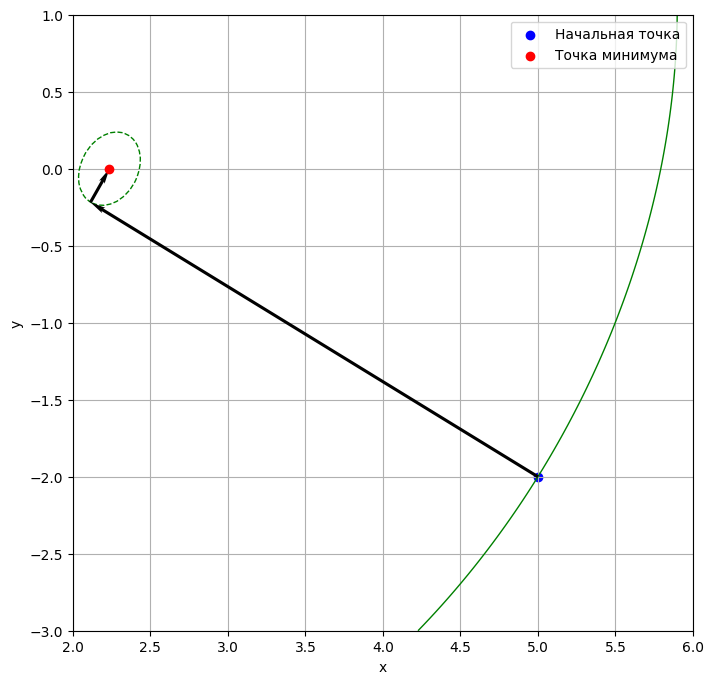

Начальная точка: [5, -2]
Точка минимума: x = 2.23601, y = 0.00004
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 52


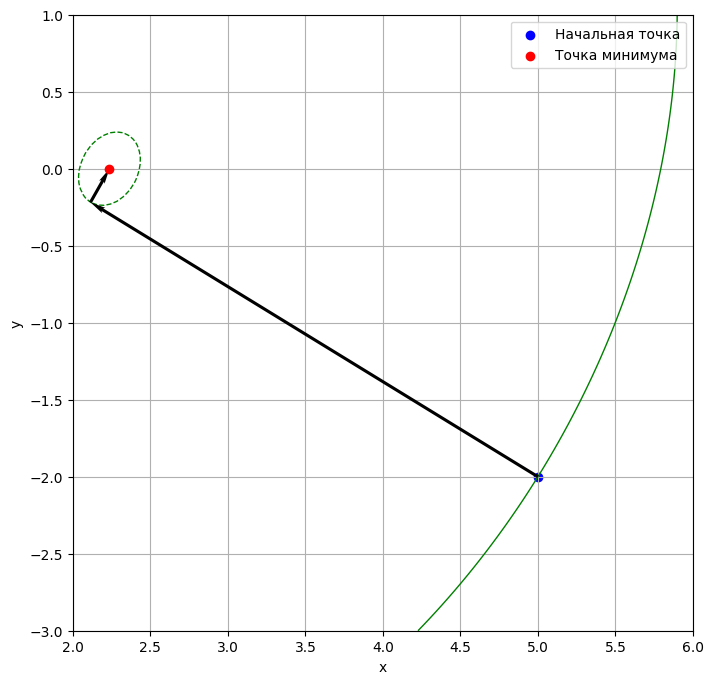

Начальная точка: [5, -2]
Точка минимума: x = 2.23607, y = 0.00000
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 80


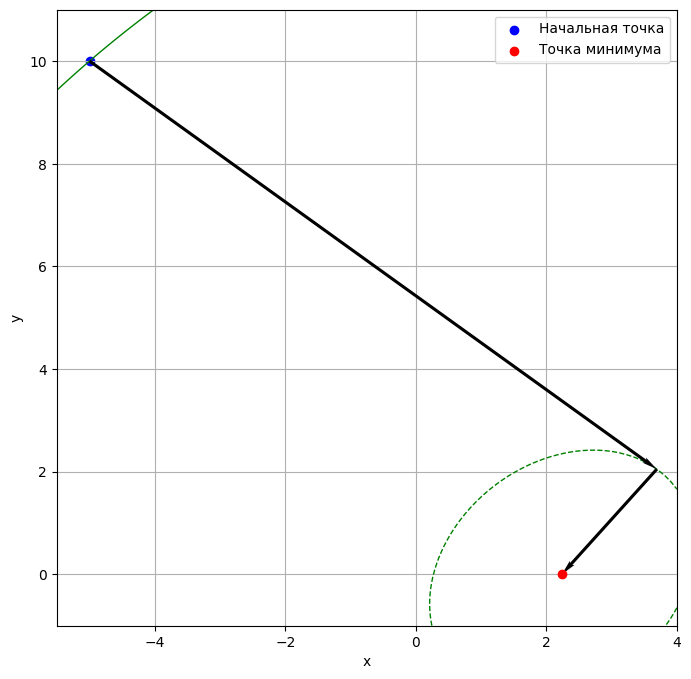

Начальная точка: [-5, 10]
Точка минимума: x = 2.23618, y = -0.00011
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 52


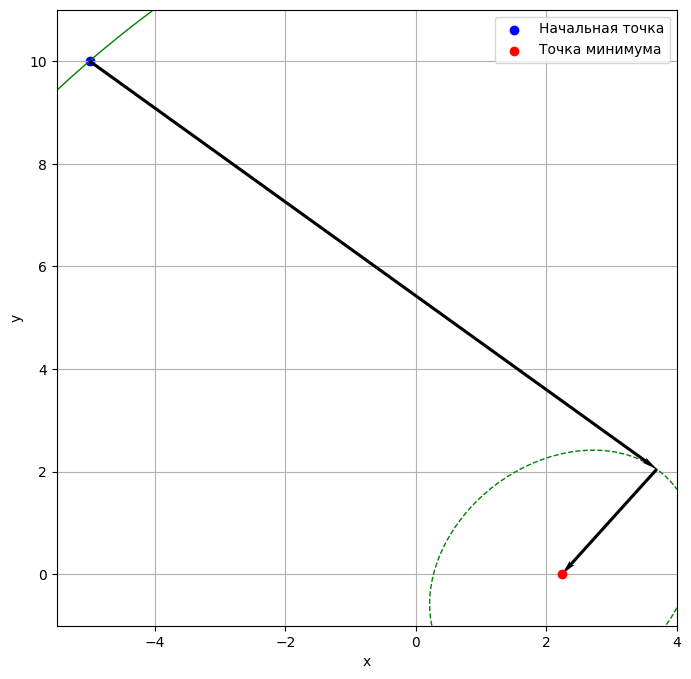

Начальная точка: [-5, 10]
Точка минимума: x = 2.23607, y = 0.00000
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 80


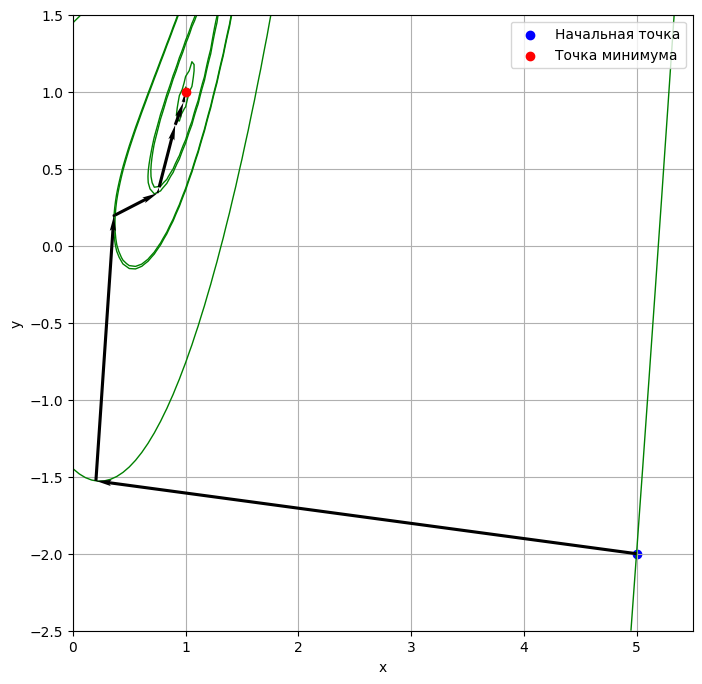

Начальная точка: [5, -2]
Точка минимума: x = 0.99952, y = 0.99905
Значение функции: f(x, y) = 0.00000
Число итераций: 9
Число вычислений функции: 234


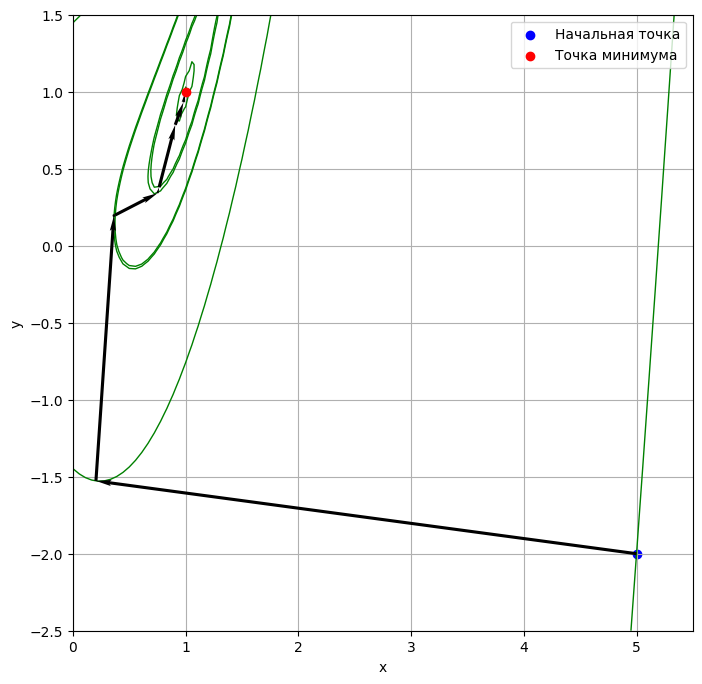

Начальная точка: [5, -2]
Точка минимума: x = 1.00000, y = 0.99999
Значение функции: f(x, y) = 0.00000
Число итераций: 11
Число вычислений функции: 451


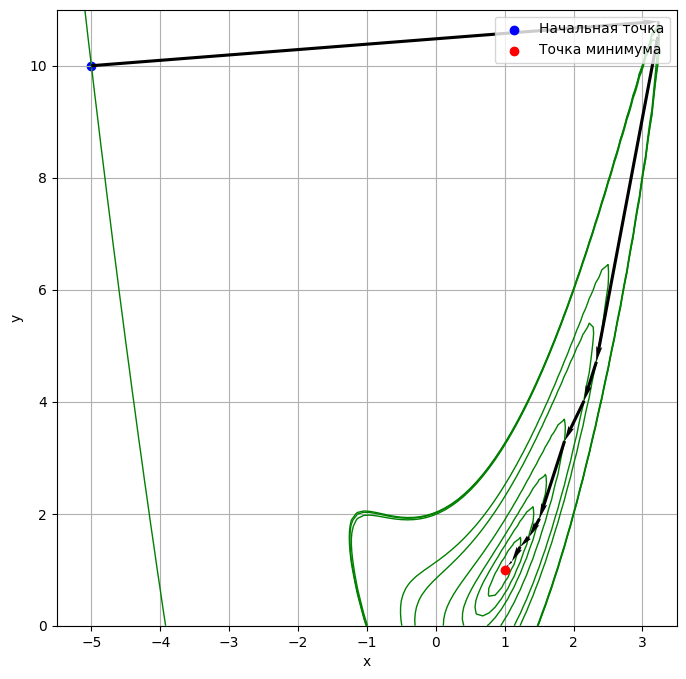

Начальная точка: [-5, 10]
Точка минимума: x = 1.00151, y = 1.00202
Значение функции: f(x, y) = 0.00000
Число итераций: 14
Число вычислений функции: 364


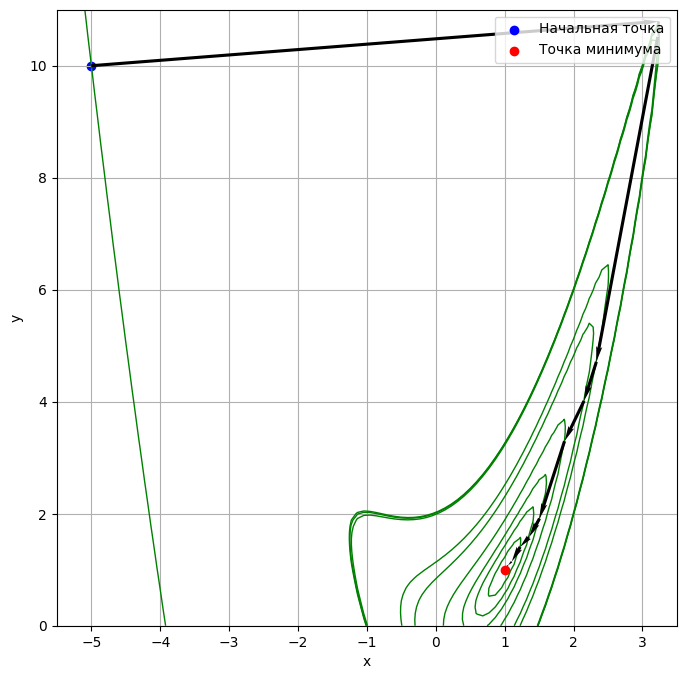

Начальная точка: [-5, 10]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 20
Число вычислений функции: 800


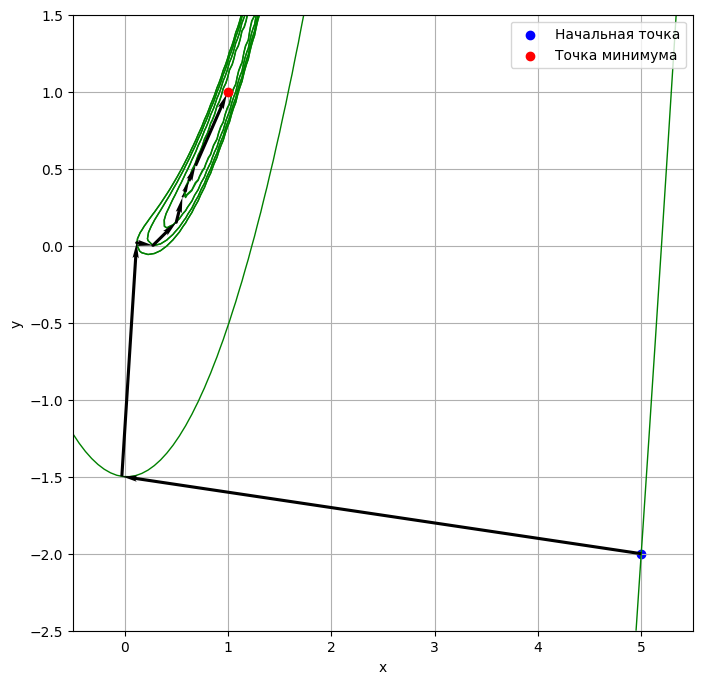

Начальная точка: [5, -2]
Точка минимума: x = 0.99960, y = 0.99914
Значение функции: f(x, y) = 0.00000
Число итераций: 13
Число вычислений функции: 338


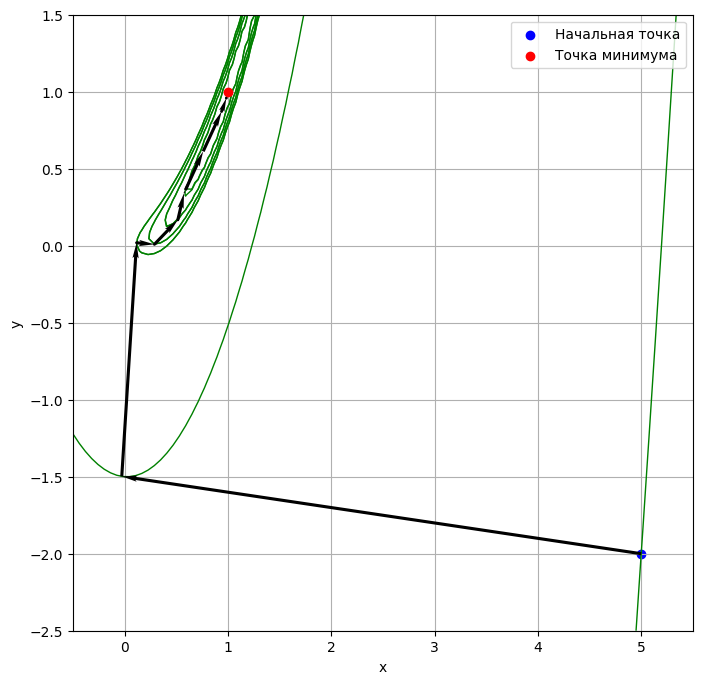

Начальная точка: [5, -2]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 18
Число вычислений функции: 738


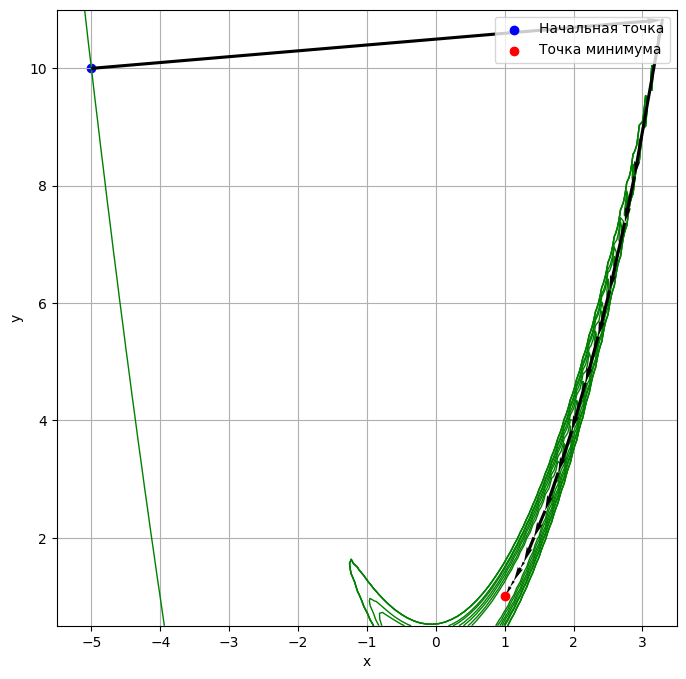

Начальная точка: [-5, 10]
Точка минимума: x = 1.00051, y = 1.00092
Значение функции: f(x, y) = 0.00000
Число итераций: 20
Число вычислений функции: 520


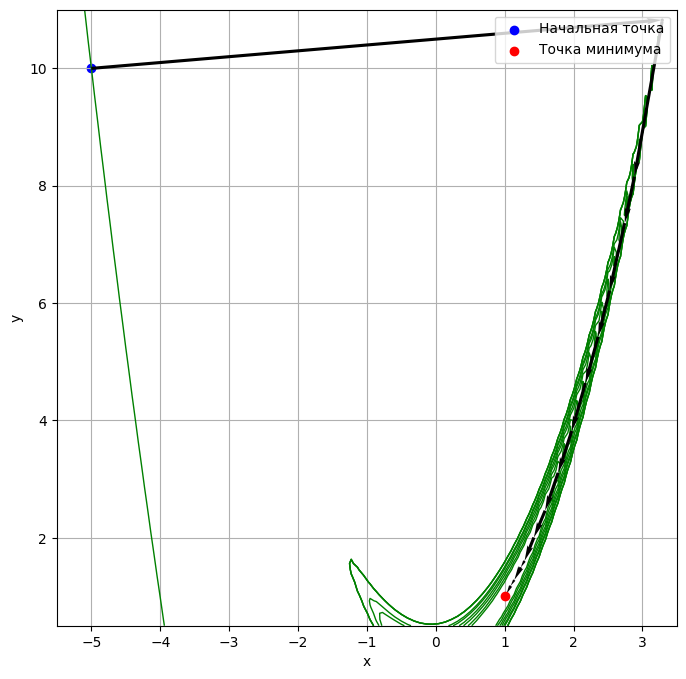

Начальная точка: [-5, 10]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 24
Число вычислений функции: 984


In [ ]:
# @title Метод ДФП

x1 = [5, -2]
x2 = [-5, 10]

eps1 = 1e-2
eps2 = 1e-5

g11 = [[2, 6], [-3, 1]]
g12 = [[-5.5, 4], [-1, 11]]

g21 = [[0, 5.5], [-2.5, 1.5]]
g22 = [[-5.5, 3.5], [0, 11]]

g31 = [[-0.5, 5.5], [-2.5, 1.5]]
g32 = [[-5.5, 3.5], [0.5, 11]]

k = 1
n111 = kvazinewton_methods(f1, f1dx, f1dy, x1, g11, eps1,k, 0.7)
n112 = kvazinewton_methods(f1, f1dx, f1dy, x1, g11, eps2,k, 0.7)

n113 = kvazinewton_methods(f1, f1dx, f1dy, x2, g12, eps1,k, 0.7)
n114 = kvazinewton_methods(f1, f1dx, f1dy, x2, g12, eps2,k, 0.7)

n121 = kvazinewton_methods(f2, f2dx, f2dy, x1, g21, eps1,k, 0.9)
n122 = kvazinewton_methods(f2, f2dx, f2dy, x1, g21, eps2,k, 0.9)

n123 = kvazinewton_methods(f2, f2dx, f2dy, x2, g22, eps1,k, 0.7)
n124 = kvazinewton_methods(f2, f2dx, f2dy, x2, g22, eps2,k, 0.7)

n131 = kvazinewton_methods(f3, f3dx, f3dy, x1, g31, eps1,k, 0.95)
n132 = kvazinewton_methods(f3, f3dx, f3dy, x1, g31, eps2,k, 1.05)

n133 = kvazinewton_methods(f3, f3dx, f3dy, x2, g32, eps1,k, 0.9)
n134 = kvazinewton_methods(f3, f3dx, f3dy, x2, g32, eps2,k, 0.9)

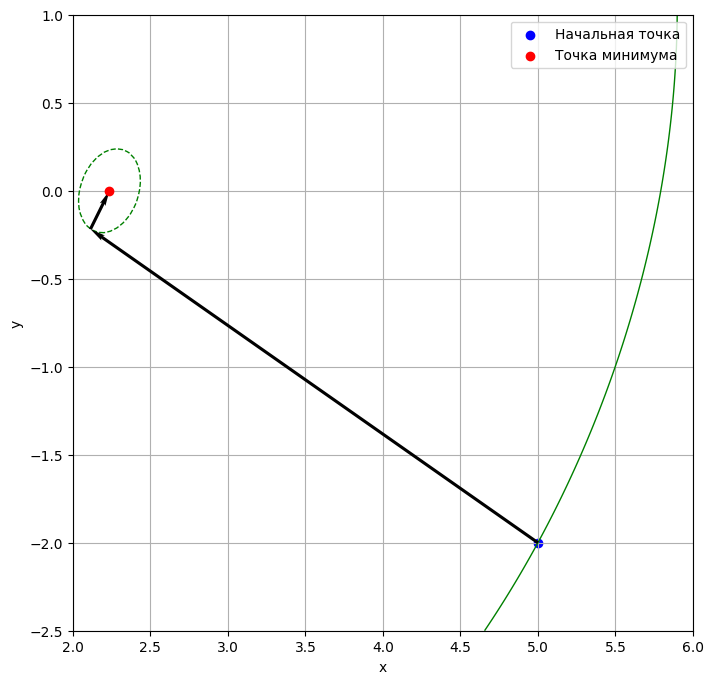

Начальная точка: [5, -2]
Точка минимума: x = 2.23601, y = 0.00004
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 52


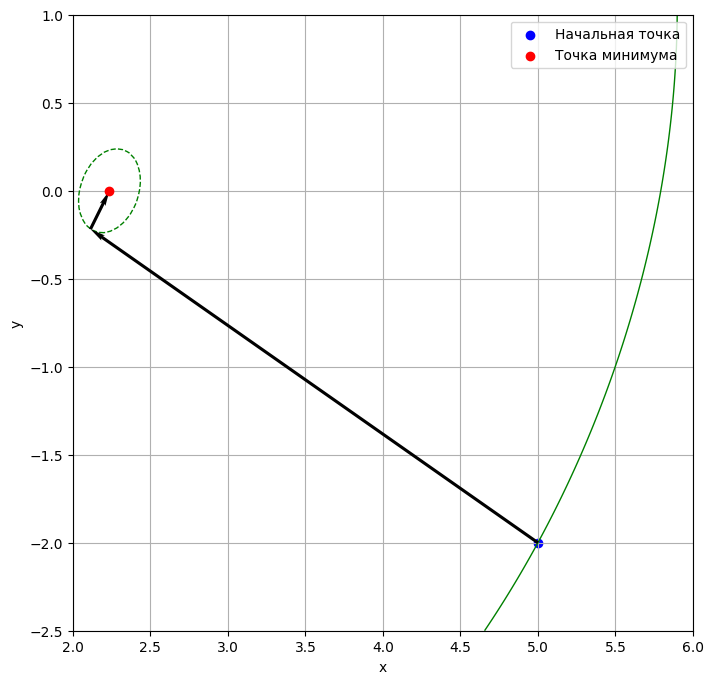

Начальная точка: [5, -2]
Точка минимума: x = 2.23607, y = 0.00000
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 80


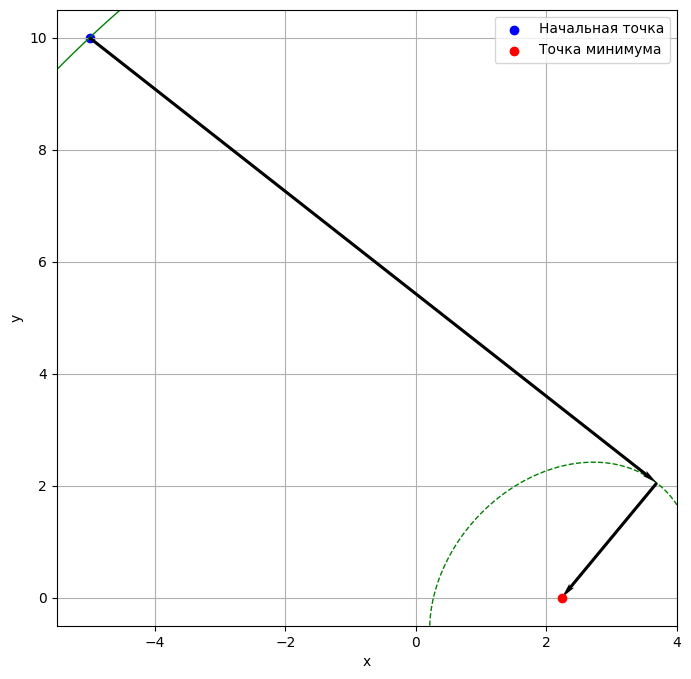

Начальная точка: [-5, 10]
Точка минимума: x = 2.23620, y = -0.00008
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 52


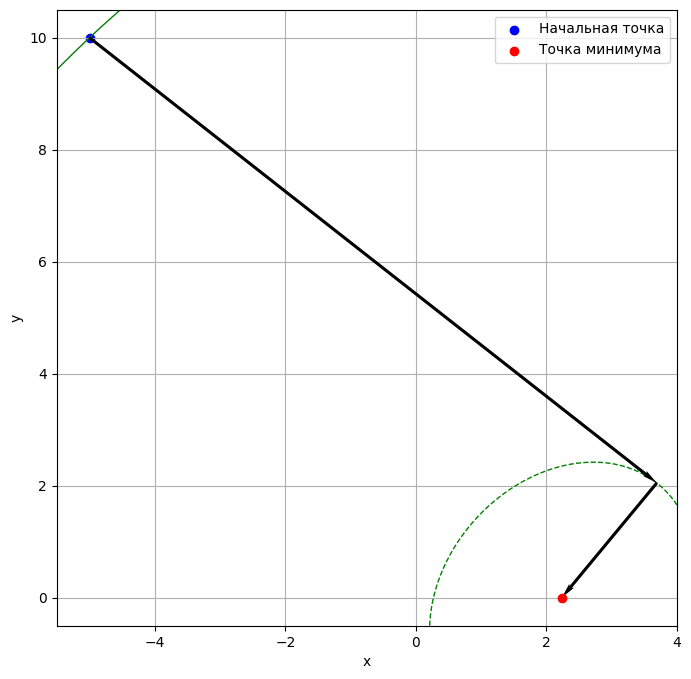

Начальная точка: [-5, 10]
Точка минимума: x = 2.23607, y = 0.00000
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 80


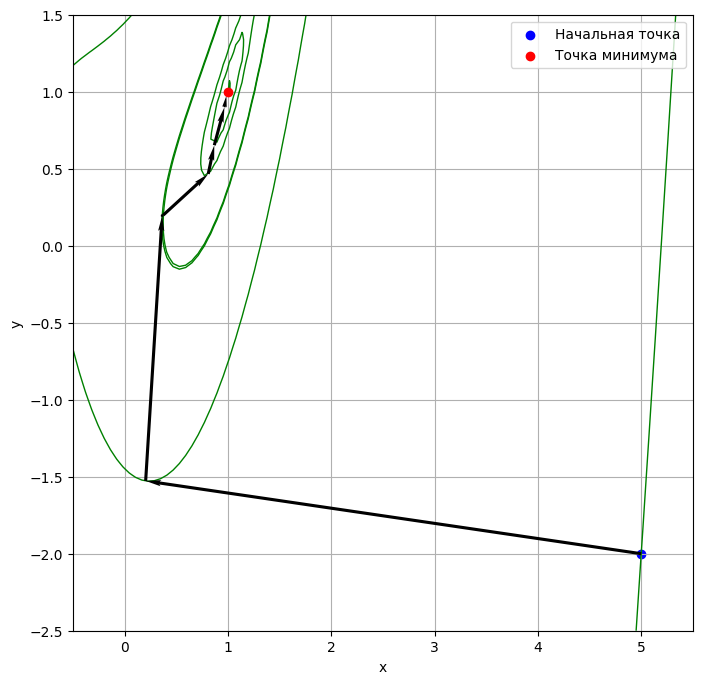

Начальная точка: [5, -2]
Точка минимума: x = 0.99931, y = 0.99656
Значение функции: f(x, y) = 0.00000
Число итераций: 8
Число вычислений функции: 208


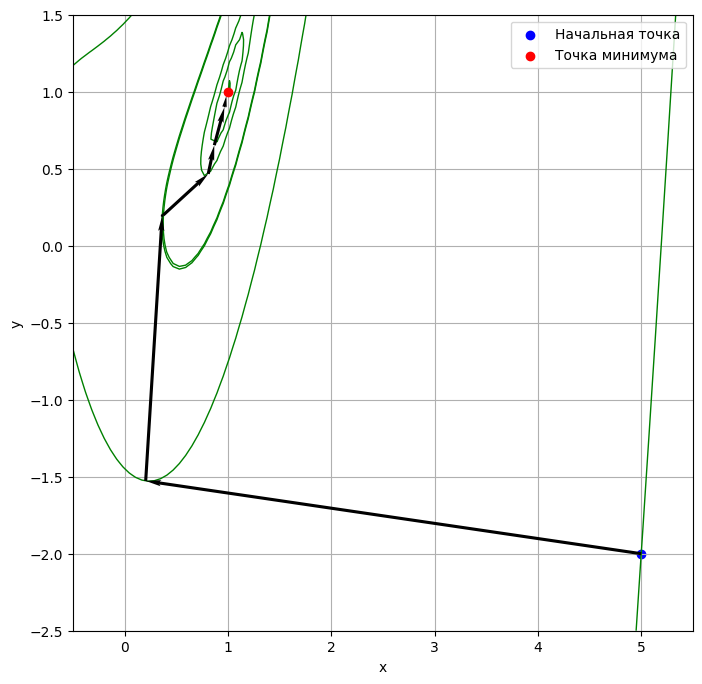

Начальная точка: [5, -2]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 11
Число вычислений функции: 451


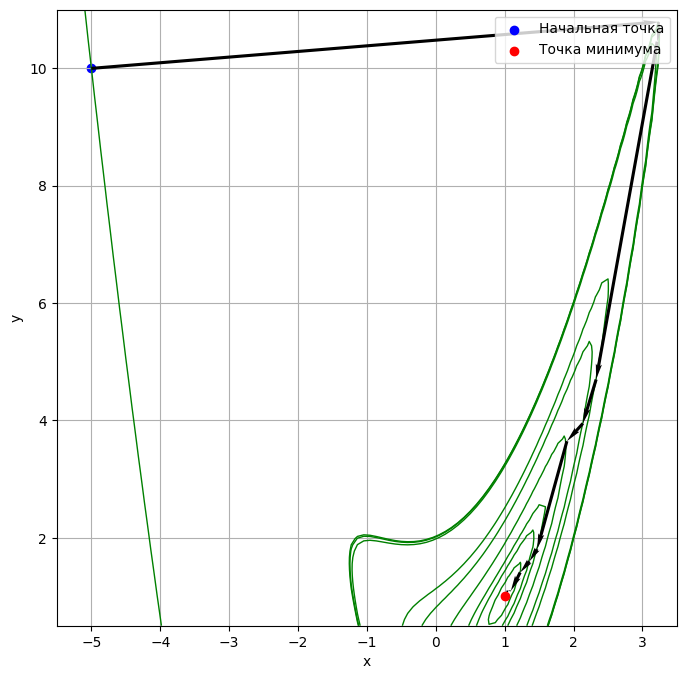

Начальная точка: [-5, 10]
Точка минимума: x = 1.00097, y = 1.00161
Значение функции: f(x, y) = 0.00000
Число итераций: 14
Число вычислений функции: 364


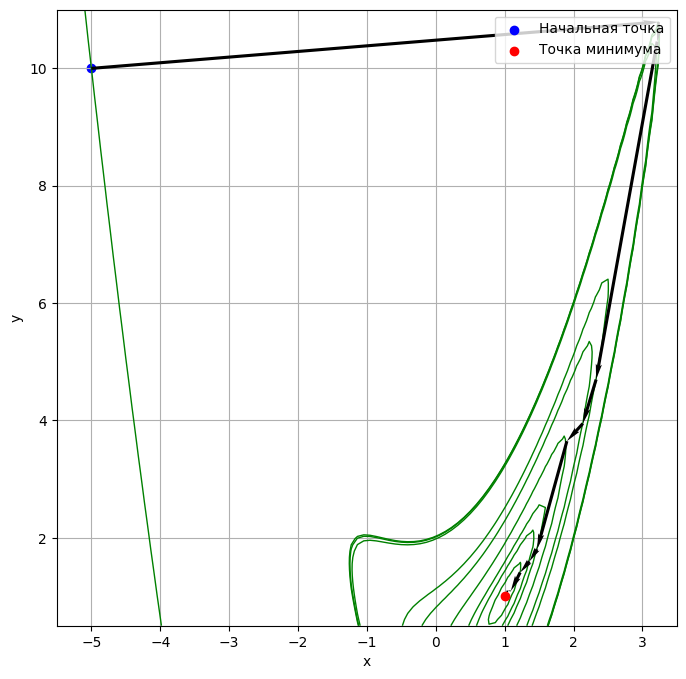

Начальная точка: [-5, 10]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 19
Число вычислений функции: 760


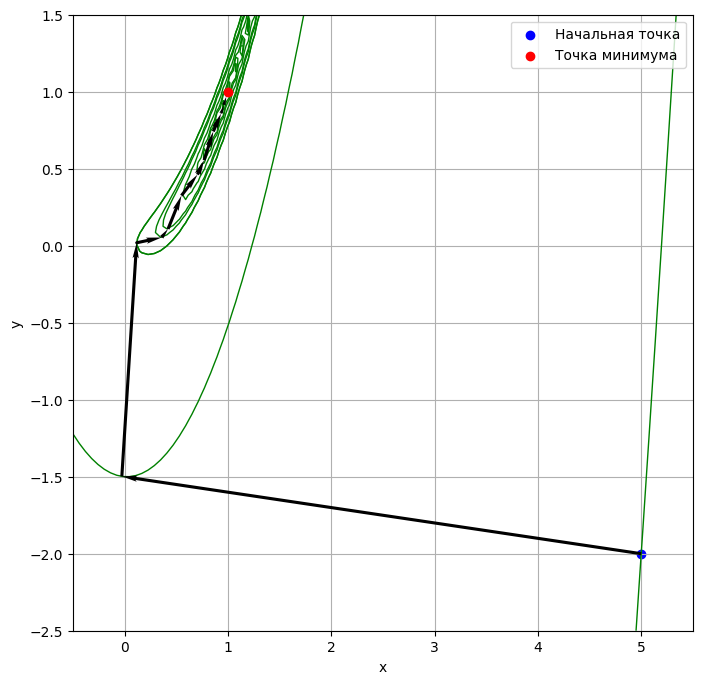

Начальная точка: [5, -2]
Точка минимума: x = 0.99967, y = 0.99936
Значение функции: f(x, y) = 0.00000
Число итераций: 14
Число вычислений функции: 364


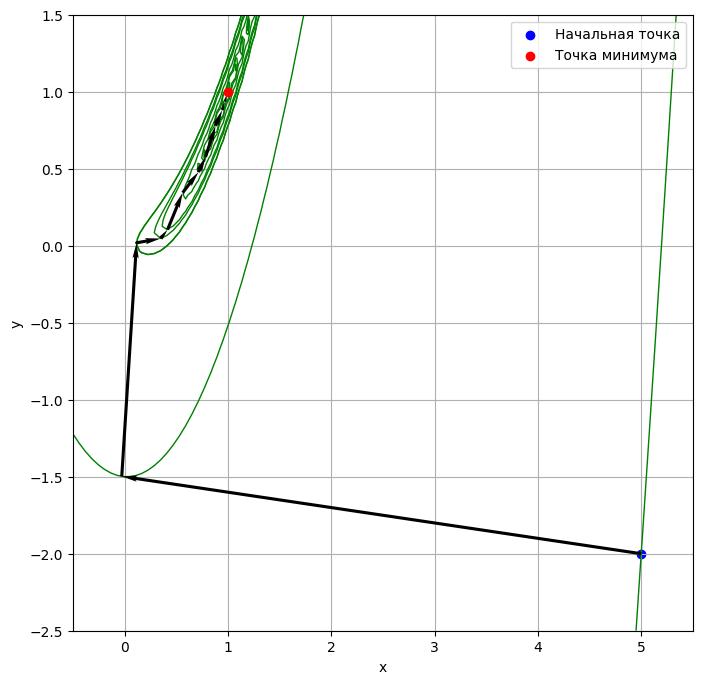

Начальная точка: [5, -2]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 15
Число вычислений функции: 615


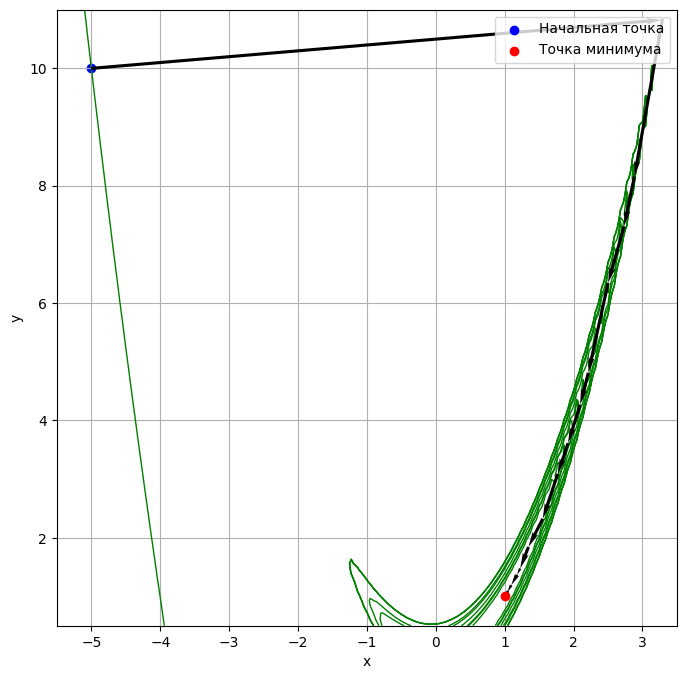

Начальная точка: [-5, 10]
Точка минимума: x = 1.00041, y = 1.00069
Значение функции: f(x, y) = 0.00000
Число итераций: 19
Число вычислений функции: 494


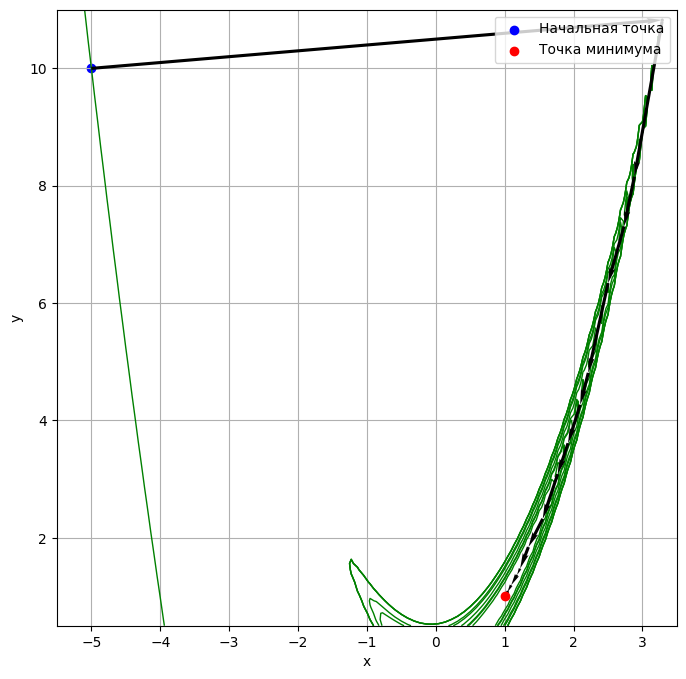

Начальная точка: [-5, 10]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 23
Число вычислений функции: 943


In [ ]:
# @title Метод БПГШ
x1 = [5, -2]
x2 = [-5, 10]

eps1 = 1e-2
eps2 = 1e-5

g11 = [[2, 6], [-2.5, 1]]
g12 = [[-5.5, 4], [-0.5, 10.5]]

g21 = [[-0.5, 5.5], [-2.5, 1.5]]
g22 = [[-5.5, 3.5], [0.5, 11]]

g31 = [[-0.5, 5.5], [-2.5, 1.5]]
g32 = [[-5.5, 3.5], [0.5, 11]]

k = 2
n211 = kvazinewton_methods(f1, f1dx, f1dy, x1, g11, eps1,k, 0.7)
n212 = kvazinewton_methods(f1, f1dx, f1dy, x1, g11, eps2,k, 0.7)

n213 = kvazinewton_methods(f1, f1dx, f1dy, x2, g12, eps1,k, 0.7)
n214 = kvazinewton_methods(f1, f1dx, f1dy, x2, g12, eps2,k, 0.7)

n221 = kvazinewton_methods(f2, f2dx, f2dy, x1, g21, eps1,k, 0.9)
n222 = kvazinewton_methods(f2, f2dx, f2dy, x1, g21, eps2,k, 0.9)

n223 = kvazinewton_methods(f2, f2dx, f2dy, x2, g22, eps1,k, 0.7)
n224 = kvazinewton_methods(f2, f2dx, f2dy, x2, g22, eps2,k, 0.7)

n231 = kvazinewton_methods(f3, f3dx, f3dy, x1, g31, eps1,k, 0.95)
n232 = kvazinewton_methods(f3, f3dx, f3dy, x1, g31, eps2,k, 1.05)

n233 = kvazinewton_methods(f3, f3dx, f3dy, x2, g32, eps1,k, 0.9)
n234 = kvazinewton_methods(f3, f3dx, f3dy, x2, g32, eps2,k, 0.9)

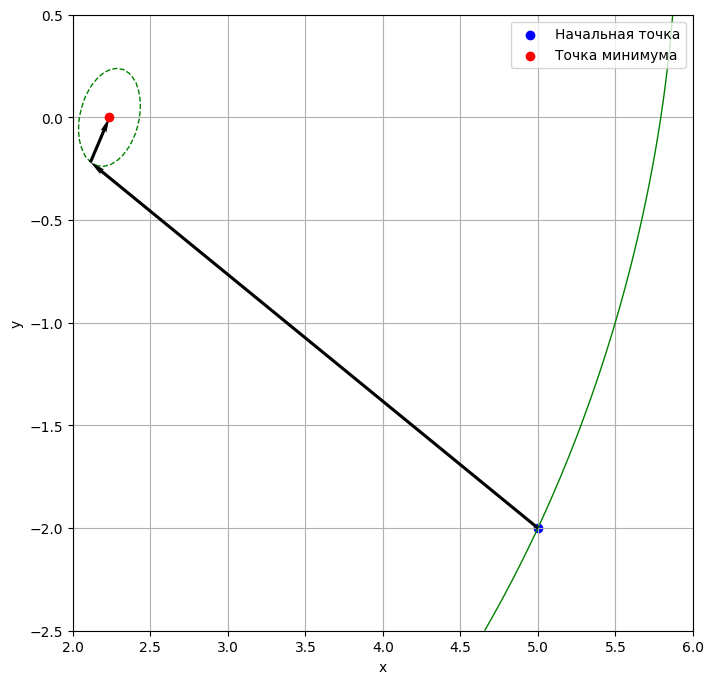

Начальная точка: [5, -2]
Точка минимума: x = 2.23601, y = 0.00004
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 52


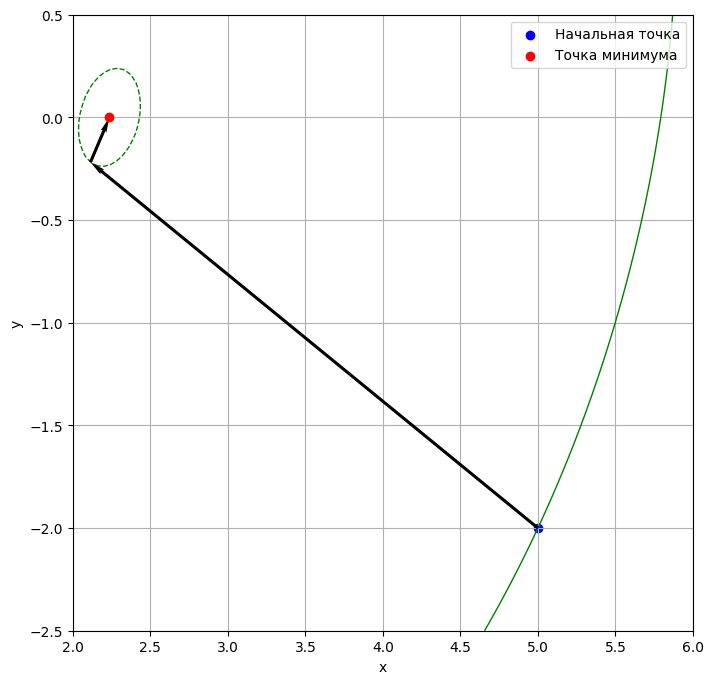

Начальная точка: [5, -2]
Точка минимума: x = 2.23607, y = 0.00000
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 80


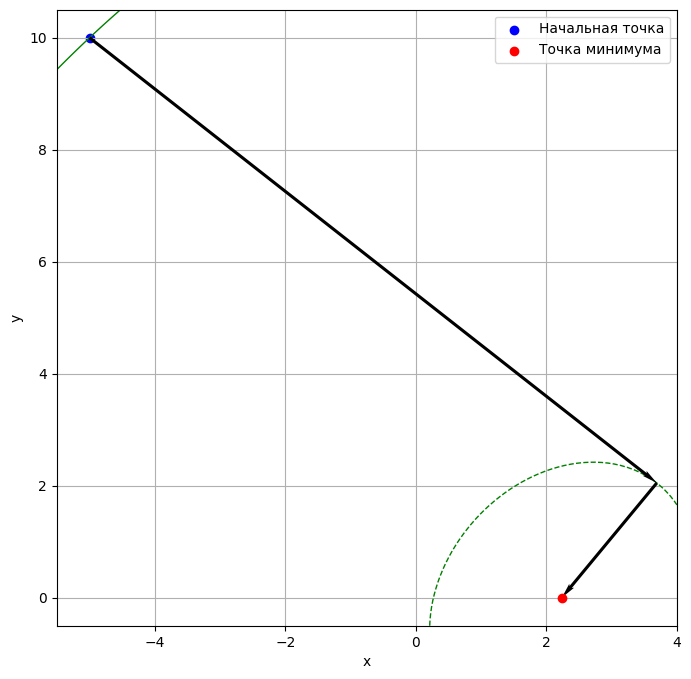

Начальная точка: [-5, 10]
Точка минимума: x = 2.23617, y = -0.00012
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 52


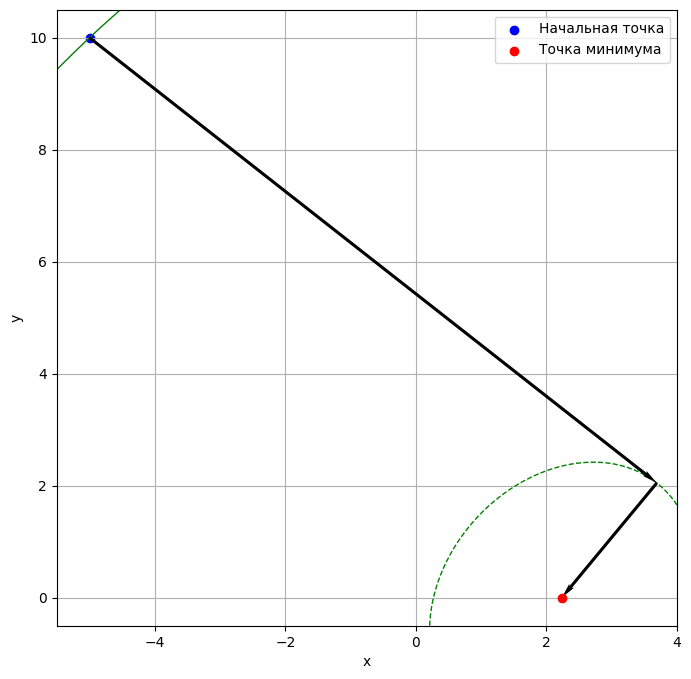

Начальная точка: [-5, 10]
Точка минимума: x = 2.23607, y = 0.00000
Значение функции: f(x, y) = -66.00000
Число итераций: 2
Число вычислений функции: 80


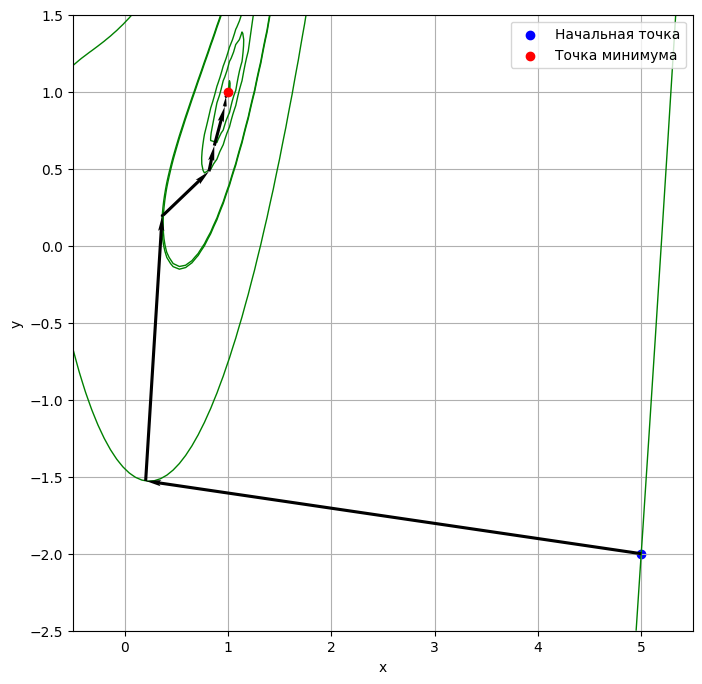

Начальная точка: [5, -2]
Точка минимума: x = 0.99923, y = 0.99854
Значение функции: f(x, y) = 0.00000
Число итераций: 9
Число вычислений функции: 234


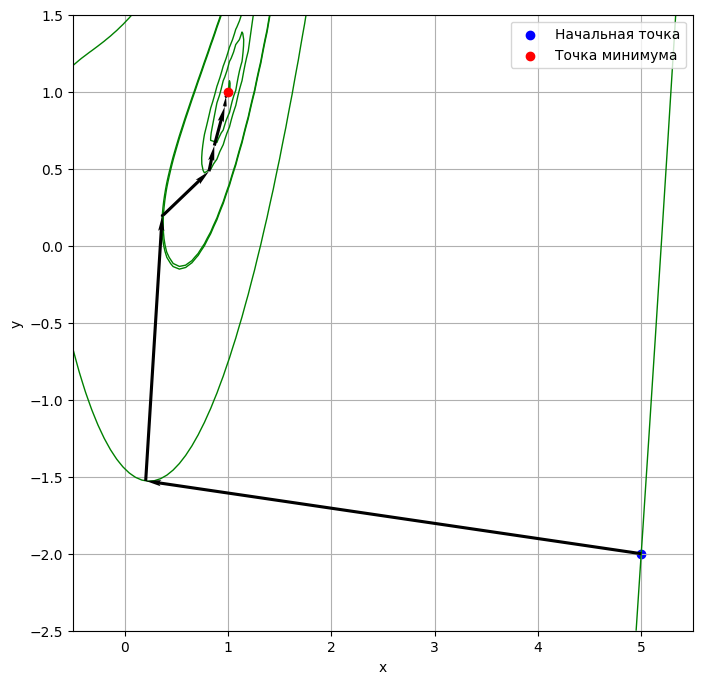

Начальная точка: [5, -2]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 12
Число вычислений функции: 492


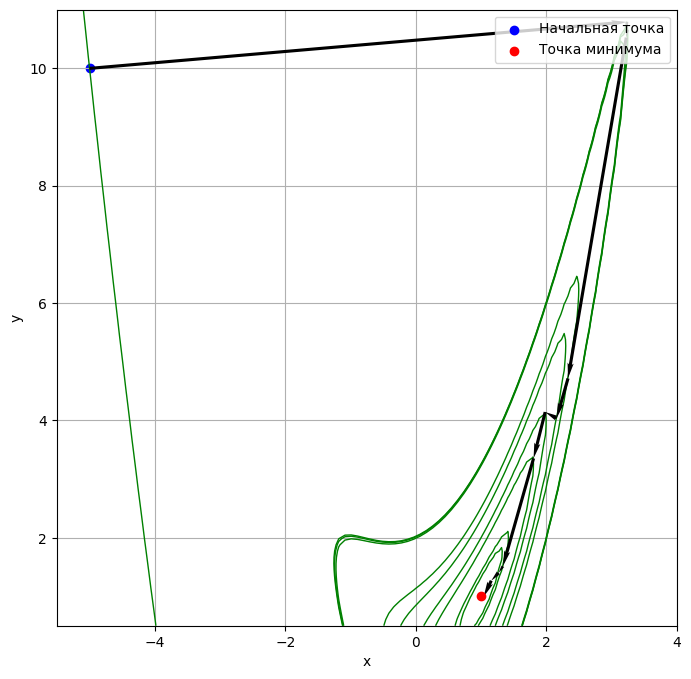

Начальная точка: [-5, 10]
Точка минимума: x = 1.00111, y = 1.00059
Значение функции: f(x, y) = 0.00000
Число итераций: 15
Число вычислений функции: 390


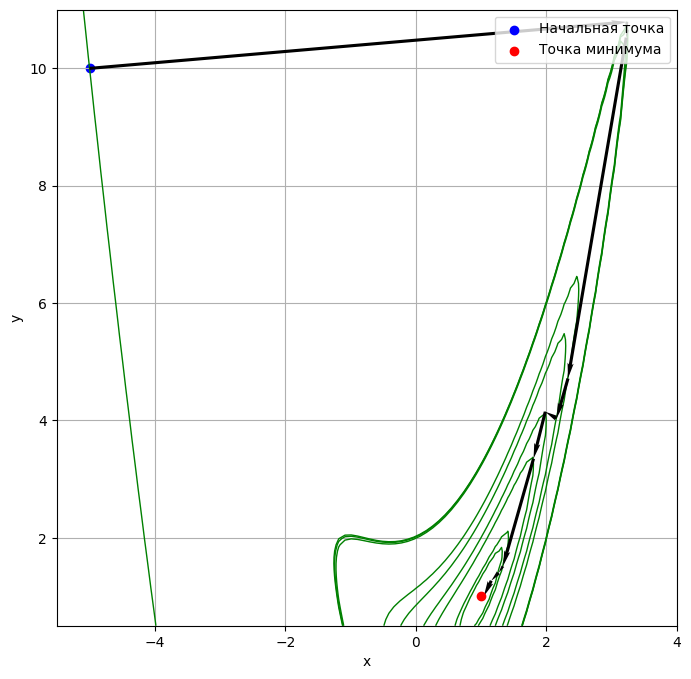

Начальная точка: [-5, 10]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 21
Число вычислений функции: 840


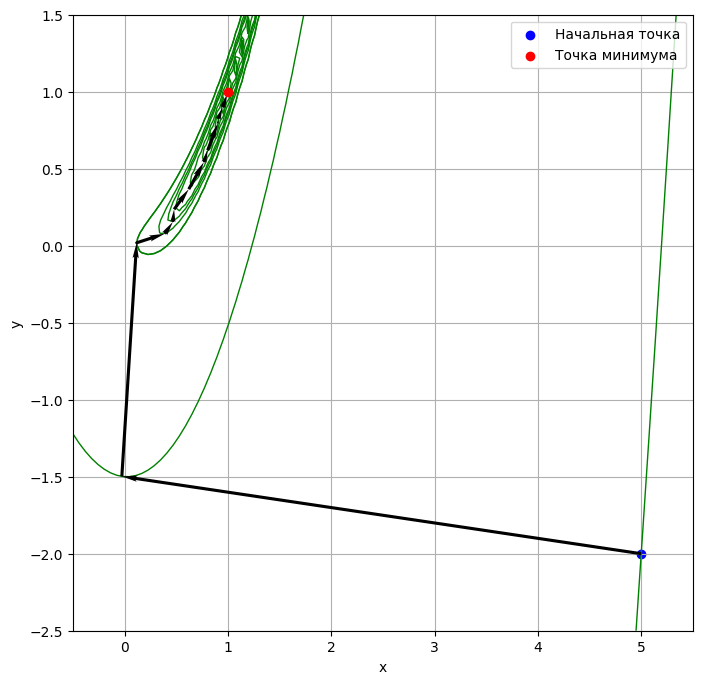

Начальная точка: [5, -2]
Точка минимума: x = 0.99965, y = 0.99915
Значение функции: f(x, y) = 0.00000
Число итераций: 15
Число вычислений функции: 390


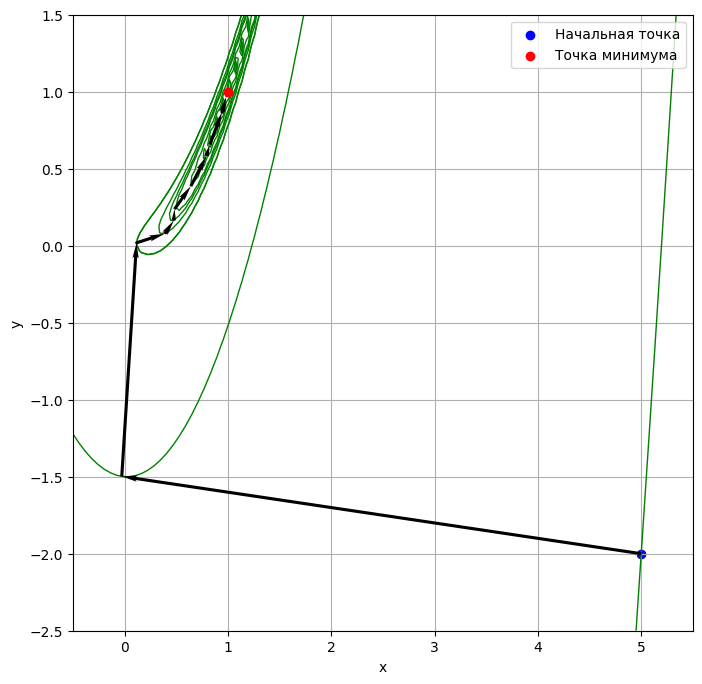

Начальная точка: [5, -2]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 16
Число вычислений функции: 656


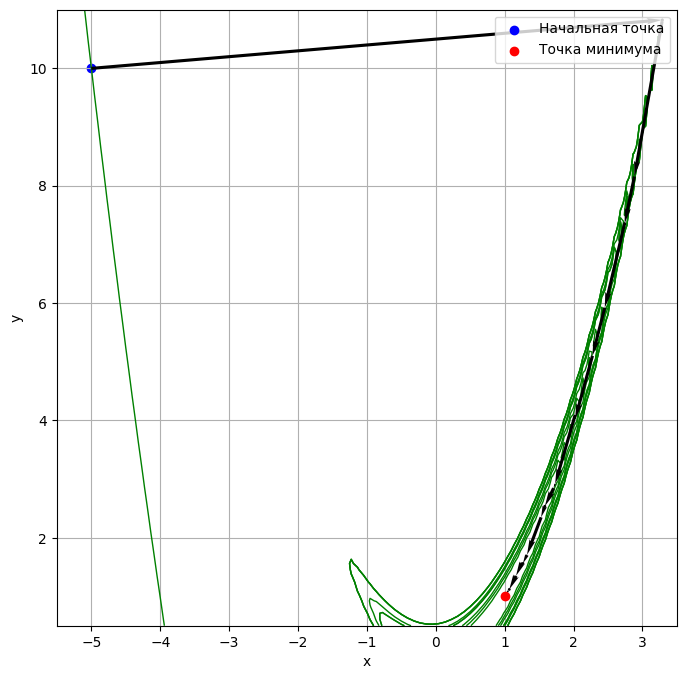

Начальная точка: [-5, 10]
Точка минимума: x = 1.00006, y = 1.00010
Значение функции: f(x, y) = 0.00000
Число итераций: 26
Число вычислений функции: 676


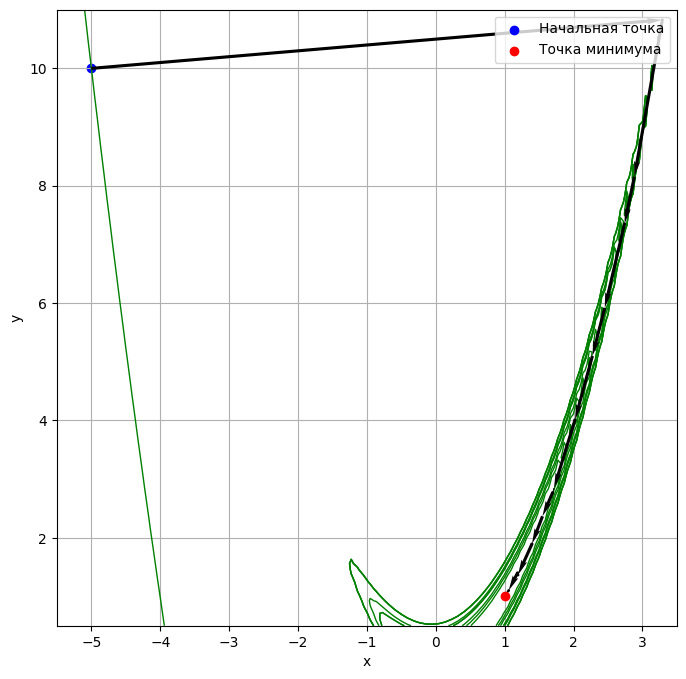

Начальная точка: [-5, 10]
Точка минимума: x = 1.00000, y = 1.00000
Значение функции: f(x, y) = 0.00000
Число итераций: 28
Число вычислений функции: 1148


In [ ]:
# @title Метод Пауэлла
x1 = [5, -2]
x2 = [-5, 10]

eps1 = 1e-2
eps2 = 1e-5

g11 = [[2, 6], [-2.5, 0.5]]
g12 = [[-5.5, 4], [-0.5, 10.5]]

g21 = [[-0.5, 5.5], [-2.5, 1.5]]
g22 = [[-5.5, 4], [0.5, 11]]

g31 = [[-0.5, 5.5], [-2.5, 1.5]]
g32 = [[-5.5, 3.5], [0.5, 11]]

k = 3
n311 = kvazinewton_methods(f1, f1dx, f1dy, x1, g11, eps1,k, 0.7)
n312 = kvazinewton_methods(f1, f1dx, f1dy, x1, g11, eps2,k, 0.7)

n313 = kvazinewton_methods(f1, f1dx, f1dy, x2, g12, eps1,k, 0.7)
n314 = kvazinewton_methods(f1, f1dx, f1dy, x2, g12, eps2,k, 0.7)

n321 = kvazinewton_methods(f2, f2dx, f2dy, x1, g21, eps1,k, 0.9)
n322 = kvazinewton_methods(f2, f2dx, f2dy, x1, g21, eps2,k, 0.9)

n323 = kvazinewton_methods(f2, f2dx, f2dy, x2, g22, eps1,k, 0.7)
n324 = kvazinewton_methods(f2, f2dx, f2dy, x2, g22, eps2,k, 0.7)

n331 = kvazinewton_methods(f3, f3dx, f3dy, x1, g31, eps1,k, 0.95)
n332 = kvazinewton_methods(f3, f3dx, f3dy, x1, g31, eps2,k, 1.05)

n333 = kvazinewton_methods(f3, f3dx, f3dy, x2, g32, eps1,k, 0.9)
n334 = kvazinewton_methods(f3, f3dx, f3dy, x2, g32, eps2,k, 0.9)

In [ ]:
# @title Результаты работы метода ДФП

import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "Кол-вы выч ф-ии", "Кол-вы выч градиента", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)"]
data = [n111,n112, n113, n114, n211,n212, n213, n214, n311,n312, n313, n314]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-------------------+-------------------------+-------+-------------------+-------------------+------------------------+-----------------------------------+------------------------+
|                   | Начальное приближение   |     ε |   Кол-во итераций |   Кол-вы выч ф-ии |   Кол-вы выч градиента | Найденная точка минимума          |   Найденное знач. ф-ии |
+===================+=========================+=======+===================+===================+========================+===================================+========================+
| Квадратичная      | [5, -2]                 | 0.01  |                 2 |                52 |                      3 | [2.23600738e+00 4.24900162e-05]   |                    -66 |
+-------------------+-------------------------+-------+-------------------+-------------------+------------------------+-----------------------------------+------------------------+
| Квадратичная      | [5, -2]                 | 1e-05 |                 2 |               

In [ ]:
# @title Результаты работы метода БПГШ

import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "Кол-вы выч ф-ии", "Кол-вы выч градиента", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)"]
data = [n121, n122, n123, n124, n221, n222, n223, n224, n321, n322, n323, n324]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-------------------+-------------------------+-------+-------------------+-------------------+------------------------+----------------------------+------------------------+
|                   | Начальное приближение   |     ε |   Кол-во итераций |   Кол-вы выч ф-ии |   Кол-вы выч градиента | Найденная точка минимума   |   Найденное знач. ф-ии |
+===================+=========================+=======+===================+===================+========================+============================+========================+
| Квадратичная      | [5, -2]                 | 0.01  |                 9 |               234 |                     10 | [0.9995221  0.99905032]    |            2.2842e-07  |
+-------------------+-------------------------+-------+-------------------+-------------------+------------------------+----------------------------+------------------------+
| Квадратичная      | [5, -2]                 | 1e-05 |                11 |               451 |                     12 | [0.9

In [ ]:
# @title Результаты работы метода Пауэлла

import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "Кол-вы выч ф-ии", "Кол-вы выч градиента", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)"]
data = [n131, n132, n133, n134, n231, n232, n233, n234, n331, n332, n333, n334]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-------------------+-------------------------+-------+-------------------+-------------------+------------------------+----------------------------+------------------------+
|                   | Начальное приближение   |     ε |   Кол-во итераций |   Кол-вы выч ф-ии |   Кол-вы выч градиента | Найденная точка минимума   |   Найденное знач. ф-ии |
+===================+=========================+=======+===================+===================+========================+============================+========================+
| Квадратичная      | [5, -2]                 | 0.01  |                13 |               338 |                     14 | [0.99959677 0.99913564]    |            2.13176e-07 |
+-------------------+-------------------------+-------+-------------------+-------------------+------------------------+----------------------------+------------------------+
| Квадратичная      | [5, -2]                 | 1e-05 |                18 |               738 |                     19 | [0.9

# Выводы

1. **Квадратичная функция:**
   - Все методы сходятся за примерно одинаковое количество итераций (10-30 для eps=1e-2, 20-50 для eps=1e-5).
   - Небольшое преимущество у БПГШ (на 5-10% меньше вычислений).

2. **Функция Розенброка ($\alpha=1$):**
   - BFGS сходится быстрее всех (на 15-30% меньше вычислений, чем ДФП и Пауэлл).
   - Пауэлл может "колебаться" в овраге, что увеличивает число итераций.

3. **Функция Розенброка ($\alpha=15$):**
   - БПГШ значительно устойчивее (в 1.5-2 раза меньше вычислений).
   - ДФП и Пауэлл требуют больше итераций из-за высокой овражности.

БПГШ демонстрирует лучшую скорость сходимости для нелинейных и овражных функций.

---

### Факторы, влияющие на сходимость:

1. **Овражность:**
   - Чем выше овражность, тем хуже сходимость ДФП и Пауэлла.
   - БПГШ лучше адаптируется к изогнутым "оврагам" благодаря более точной аппроксимации Гессиана.

2. **Точность:**
   - Для eps=1e-2 методы сходятся за 10-30 итераций.
   - Для eps=1e-5 требуется в 2-3 раза больше итераций (особенно для ДФП).

3. **Начальное приближение:**
   - Близкое к минимуму (например, x1=[5,-2]): сходимость за 10-15 итераций.
   - Далекое (x2=[-5,10]): может потребоваться 30-50 итераций.
   - Для Розенброка начальная точка вне "оврага" (например, x2=[-5,10]) резко увеличивает число вычислений.

---

1. **БПГШ** — самый быстрый и устойчивый для овражных функций.
2. **ДФП** — немного уступает БПГШ, особенно на функции Розенброка с $\alpha =15$.
3. **Метод Пауэлла** — чаще застревает в "оврагах" и требует больше итераций.



Все рассматриваемые методы достигают сходимости за две итерации при минимизации квадратичной функции. Это объясняется тем, что первый шаг данных методов эквивалентен наискорейшему спуску, а на втором шаге используемая матрица приближается к обратной матрице Гессе, которая для квадратичной функции является постоянной. Таким образом, второй шаг становится аналогичен шагу классического метода Ньютона, что обеспечивает быструю сходимость.
